# Analysis of enumerated molecules

### Aim of this notebook 

We create two enumeration subsets, one with fragments from CustomKinFragLib, one with fragments rejected by CustomKinFragLib filters. We compare these enumerated subsets regarding drug-like properties and synthesizability. 

## Table of contents
1. Load the fragment libraries

    1.1. Load pre-filtered fragment library
    
    1.2. Load custom-filtered fragment library
    

2. Select fragments for recombination sets
    
    2.1. Sample fragments from CustomKinFragLib  
    
    2.2. Sample fragments from KinFragLib 


3. Recombination of molecules 


4. Load combinatorial library and deduplicate

    4.1 Load CustomKinFragLib combinatorial library

    4.2 Load combinatorial library based on rejected fragments 
    

5. Sample enumerated ligands 

    5.1 Get subpocket frequencies 

    5.2 Sample enumerated molecules 


6. Molecular property analysis of enumerated molecules 

    6.1. Drug-like properties 

    * Lipinski's Rule of 5 and Veber's rule 
    * QED score 

    6.2. Synthesizability 

    * SYBA score 
    * Similarity to Enamine REAL Space 


## Imports and preprocessing

In [1]:
from pathlib import Path 
from rdkit import Chem 
from rdkit.Chem import Lipinski, Descriptors, QED

import pandas as pd 
import numpy as np
import sys
import os
from kinfraglib import utils, filters
import matplotlib.pyplot as plt 
from syba.syba import SybaClassifier


### Define paths 

In [2]:
HERE = Path(_dh[-1])
PATH_TO_DATA = HERE / '..' / '..' / 'data' 

In [3]:
# paths for sampled fragment libraries 
original_lib_path = PATH_TO_DATA / 'prefiltered_fragment_library'
lib_path = PATH_TO_DATA / 'custom_fragment_library_sampled'
ref_lib_path = PATH_TO_DATA / 'reference_fragment_library_sampled'


## 1. Load fragment libraries 

- Read pre-filtered fragment library
- Read custom filtered fragment library

### 1.1 Load pre-filtered fragment library

In [4]:
fragment_library = utils.read_fragment_library(PATH_TO_DATA / "fragment_library")
fragment_library = filters.prefilters.pre_filters(fragment_library)
pd.concat(fragment_library).shape
# NBVAL_CHECK_OUTPUT

(3414, 19)

### 1.2 Load custom-filtered fragment library

In [5]:
custom_fragment_library = utils.read_fragment_library(PATH_TO_DATA / 'fragment_library_custom_filtered')
pd.concat(custom_fragment_library).shape
# NBVAL_CHECK_OUTPUT

(837, 15)

## 2. Select fragments for recombination space

### 2.1 Sample fragments from CustomKinFragLib

In [6]:
# select random fragments from each pocket  
num_fragments = 80
pocket_df = {}
np.random.seed(1)
for p in custom_fragment_library.keys(): 
    subpocket_length = len(custom_fragment_library[p])
    sampled_ind = np.random.choice(subpocket_length, min(subpocket_length, num_fragments), replace=False)
    df = custom_fragment_library[p][custom_fragment_library[p].index.isin(sampled_ind)]
    pocket_df[p] = df
    for ind in pocket_df[p].index: 
        pocket_df[p].loc[ind].ROMol_original.SetProp("Index", str(ind))
    

In [7]:
[(key, len(val)) for key, val in pocket_df.items()]
# NBVAL_CHECK_OUTPUT

[('AP', 80), ('FP', 80), ('SE', 80), ('GA', 80), ('B1', 18), ('B2', 26)]

In [8]:
def save_fragment_library_to_sdfs(path_output, fragment_library_concat):
    """
    Save fragment library to file (for each subpocket sdf file).
    
    Parameters
    ----------
    path_output : str or pathlib.Path
        Path to output folder for sdf files.
    fragment_library_concat : pandas.DataFrame
        Fragment library data for one or multiple subpockets.
    """
    
    #path_output = Path(path_output)
    path_output.mkdir(parents=True, exist_ok=True)
    
    for subpocket, fragments in fragment_library_concat.groupby('subpocket'):
        
        with Chem.SDWriter(str(path_output / f"{subpocket}.sdf")) as w:
            for mol in fragments.ROMol_original:
                w.write(mol)

### 2.2 Sample fragments from KinFragLib 

When sampling these fragments, we first exclude all fragments that are included in CustomKinFragLib. 

In [10]:
# extract PDB for all fragments in CustomKinFragLib 
custom_pdbs = {}
for p in custom_fragment_library.keys(): 
    custom_pdbs[p] = list(custom_fragment_library[p].complex_pdb)

num_fragments_reference = 80
np.random.seed(1)
reference_library = {}
for p in fragment_library.keys(): 
    # exclude all customkinfraglib fragments from KinFragLib
    new_inds = []
    for i, row in fragment_library[p].iterrows(): 
        if row.complex_pdb not in custom_pdbs[p]: 
            new_inds.append(i)
    # sample fragments from remaining KinFragLib 
    subpocket_length = len(new_inds)
    sampled_ind = np.random.choice(subpocket_length, min(subpocket_length, num_fragments_reference), replace=False)
    df = fragment_library[p][fragment_library[p].index.isin(sampled_ind)]
    reference_library[p] = df
    # reset index 
    for ind in reference_library[p].index: 
        reference_library[p].loc[ind].ROMol_original.SetProp("Index", str(ind))


In [11]:
[(key, len(val)) for key, val in reference_library.items()]
# NBVAL_CHECK_OUTPUT

[('AP', 80), ('FP', 80), ('SE', 80), ('GA', 80), ('B1', 29), ('B2', 33)]

In [12]:
# write reference fragments to file 
save_fragment_library_to_sdfs(ref_lib_path, pd.concat(reference_library))

In [13]:
# write pre-filtered library to file
save_fragment_library_to_sdfs(original_lib_path, pd.concat(fragment_library))

## 3. Recombination of molecules

We use the functionalities of KFFL ([KinaseFocusedFragmentLibrary](https://github.com/volkamerlab/kinasefocusedfragmentlibrary)) for recombination. The notebook `docs/notebooks/ligand_recombination/ligand_recombination.ipynb` in the KFFL repository contains the code used for recombination. 

The recombination set is available on zenodo for download and place them in this repository to execute the rest of the notebook. 

## 4. Read combinatorial library and deduplicate
The deduplication is done based on the fragment IDs for all ligands.

In [14]:
def sort_ligand_name(lig_name):
    """Sort fragments in ligand name

    Args:
        lig_name (str): string with all fragments present

    Returns:
        str: ligand name with fragments sorted alphabetically
    """
    lig_name = sorted(lig_name.split(","))
    lig_name = ",".join(lig_name)
    return lig_name


In [15]:
def deduplicate(mols): 
    """Deduplicate molecules based on sorted ligand name (fragment IDs)

    Args:
        mols (list): List of molecules to be deduplicated

    Returns:
        list: Deduplicated list of molecules 
    """
    lig_name_dict = {}
    for mol in mols: 
        if mol is not None:  
            lig_name = sort_ligand_name(mol.GetProp("frag_ids"))
            if lig_name not in lig_name_dict: 
                lig_name_dict[lig_name] = mol 

    mols_dedup = list(lig_name_dict.values())
    return mols_dedup

### 4.1 Load CustomKinFragLib combinatorial library 
**Note**: Reading the SDF might take around five minutes. 

In [16]:
mols = [mol for mol in Chem.SDMolSupplier(str(PATH_TO_DATA / "combinatorial_library" / "combinatorial_library_custom_sampled.sdf"))]
mols = deduplicate(mols)
len(mols)
# NBVAL_CHECK_OUTPUT

786212

### 4.2 Load combinatorial library from rejected fragments 

**Note**: Reading the SDF might take around five minutes. 

In [17]:
mols_ref = [mol for mol in Chem.SDMolSupplier(str(PATH_TO_DATA / "combinatorial_library" / "combinatorial_library_rejected_sampled.sdf"))]
mols_ref = deduplicate(mols_ref)
len(mols_ref)
# NBVAL_CHECK_OUTPUT

774070

## 5. Sample enumerated ligands 

We aim to subsample the enumerated space to create a chemical space that is more similar to actual kinase ligands, such as ligands recorded in KLIFS. 

### 5.1 Get subpocket frequencies 

We want to extract how large kinase ligands usually are, in our case how many fragments are usually present in a kinase ligand. Using this information, we can build a more reasonable chemical space with ligands that have a similar size to known kinase ligands (in KLIFS). 

This section of the notebook is taken from **KinFragLib Notebook 2.2**. 

In [18]:
# read unfiltered KinFragLib library 
fragment_library_original = utils.read_fragment_library(PATH_TO_DATA / 'fragment_library')
fragment_library_concat = pd.concat(fragment_library_original.values())
# Remove pool X
fragment_library_concat_wo_x = fragment_library_concat[
    fragment_library_concat.subpocket != 'X'
].copy()

In [19]:
n_subpockets_per_ligand = fragment_library_concat_wo_x.groupby(
    ['kinase', 'complex_pdb', 'ligand_pdb', 'subpocket']
).first().reset_index().groupby(
    ['kinase', 'complex_pdb', 'ligand_pdb']
).size()

In [20]:
n_subpockets_per_ligand_distribution = pd.concat(
    [
        n_subpockets_per_ligand.value_counts().sort_index().rename('ligand_count'),
        n_subpockets_per_ligand.value_counts(normalize=True).sort_index().rename('ligand_frequency')
    ],
    axis=1
)
n_subpockets_per_ligand_distribution

,ligand_count,ligand_frequency
1,147,0.045483
2,964,0.298267
3,1639,0.507116
4,435,0.134592
5,44,0.013614
6,3,0.000928


### 5.2 Sample enumerated molecules

We sample a subset of the enumerated molecules to keep the fraction of molecules with 2, 3, or 4 fragments the same as in known kinase ligands (KLIFS).

In [21]:
def split_mols(mols): 
    """Divide the recombined molecules by number of fragments 

    Args:
        mols (list): List of RDKit molecules, containing the recombined molecules 

    Returns:
        dict: Containing a list of molecules for each number of fragments. 
    """
    mols_subset = {}
    for mol in mols: 
        lig_name = mol.GetProp("frag_ids").split(",")
        if len(lig_name) in mols_subset: 
            mols_subset[len(lig_name)].append(mol)
        else: 
            mols_subset[len(lig_name)] = [mol]
    return mols_subset

In [22]:
def total_sampled_mols(split_mols_ref, n_subpockets_per_ligand_distribution): 
    """Calculate the maximum number of molecules we can sample for our chemical space. 
    This is done, because the number of molecules with more fragments is exponentially 
    larger and we want to balance this number based on frequencies of fragment numbers 
    instead. We base the number of total molecules based on the number of molecules 
    with the least number of fragments. 

    Args:
        split_mols_ref (dict): contains a list with molecules for each number of fragments per molecule
        n_subpockets_per_ligand_distribution (pd.DataFrame): contains frequencies for the number of fragments 

    Returns:
        dict: number of molecules that we should sample for each number of fragments 
    """
    min_frag = min(split_mols_ref.keys())
    min_freq = n_subpockets_per_ligand_distribution.loc[min_frag].ligand_frequency  
    total_sampled = 1 / min_freq * len(split_mols_ref[min_frag]) 
    frag_numbers = {}
    for num in split_mols_ref.keys(): 
        frag_numbers[num] = int(total_sampled * n_subpockets_per_ligand_distribution.loc[num].ligand_frequency)
    return frag_numbers

In [23]:
split_mols_ref = split_mols(mols_ref)


In [24]:
split_mols_custom = split_mols(mols)

In [25]:
# rejected molecules 
# set seed
np.random.seed(1)
frag_numbers = total_sampled_mols(split_mols_ref, n_subpockets_per_ligand_distribution)
sampled_mols = []
for num in frag_numbers.keys(): 
    # sample molecules
    sampled_mols += list(np.random.choice(split_mols_ref[num], frag_numbers[num], replace=False))

In [26]:
# sample CustomKinFragLib ligands 
np.random.seed(1)
frag_numbers_custom = total_sampled_mols(split_mols_custom, n_subpockets_per_ligand_distribution)
sampled_mols_custom = []
for num in frag_numbers_custom.keys(): 
    sampled_mols_custom += list(np.random.choice(split_mols_custom[num], frag_numbers_custom[num], replace=False))

In [27]:
# write our new chemical space to file 
with Chem.SDWriter(str(lib_path / "sampled_mols_custom.sdf")) as mol_file:
    for m in sampled_mols_custom:
        mol_file.write(m)

In [28]:
with Chem.SDWriter(str(ref_lib_path / "sampled_mols_reference.sdf")) as mol_file:
    for m in sampled_mols:
        mol_file.write(m)

## 6. Molecular property analysis of enumerated molecules 

### 6.1 Drug-like properties

Calculate molecular properties from Lipinski's Rule of 5 and Veber's rule. Record thresholds and how many molecules are passing each filter. 

In [29]:
def calculate_prop(mols): 
    """Calculate molecular properties, applies Lipinski's and Veber's rules

    Args:
        mols (list): List of RDKit molecules

    Returns:
        list: List with summary statistics for each property and the overall Lipinski's rule 
    """
    # calculate molecular properties 
    hba = [Lipinski.NumHAcceptors(mol) for mol in mols]
    hbd = [Lipinski.NumHDonors(mol) for mol in mols]
    nrot = [Lipinski.NumRotatableBonds(mol) for mol in mols]
    mw = [Descriptors.MolWt(mol) for mol in mols]
    logp = [Descriptors.MolLogP(mol) for mol in mols]
    tpsa = [Descriptors.TPSA(mol) for mol in mols]

    # calculate rule of 5 
    mw_bool = [weight <= 500 for weight in mw]
    hba_bool = [acc <= 10 for acc in hba]
    hbd_bool = [don <= 5 for don in hbd]
    nrot_bool = [rot_bonds < 10 for rot_bonds in nrot]
    tpsa_bool = [polar_surface < 140 for polar_surface in tpsa]
    logp_bool = [logp_val <= 5 for logp_val in logp]

    # lipinski filter 
    lipinski_bool = []
    for i, mw_val in enumerate(mw_bool): 
        lipinski_bool.append(all([mw_val, hba_bool[i], hbd_bool[i], nrot_bool[i], tpsa_bool[i], logp_bool[i]]))

    # fraction of passes for each rule and total 
    summary_stats = [sum(mw_bool) / len(mw_bool) * 100, 
                  sum(hba_bool) / len(hba_bool) * 100, 
                  sum(hbd_bool) / len(hbd_bool) * 100, 
                  sum(nrot_bool) / len(nrot_bool) * 100, 
                  sum(tpsa_bool) / len(tpsa_bool) * 100, 
                  sum(logp_bool) / len(logp_bool) * 100, 
                  sum(lipinski_bool) / len(lipinski_bool) * 100]
    
    return summary_stats


In [30]:
custom_summary_subset = calculate_prop(sampled_mols_custom)
reference_summary_subset = calculate_prop(sampled_mols)

In [41]:
# Collect data in one DataFrame
bar_data_subset = pd.DataFrame(
    {
        f'Ligands from rejected fragments (#{len(sampled_mols)})': reference_summary_subset, 
        f'CustomKinFragLib ligands (#{len(sampled_mols_custom)})': custom_summary_subset, 
    }
)
bar_data_subset.index.name = None
bar_data_subset

,Ligands from rejected fragments (#19053),CustomKinFragLib ligands (#21618)
0,74.486957,87.242113
1,91.067024,99.481913
2,95.895659,99.962994
3,95.622737,99.366269
4,79.105653,97.724119
5,78.785493,77.375335
6,55.692017,72.078823


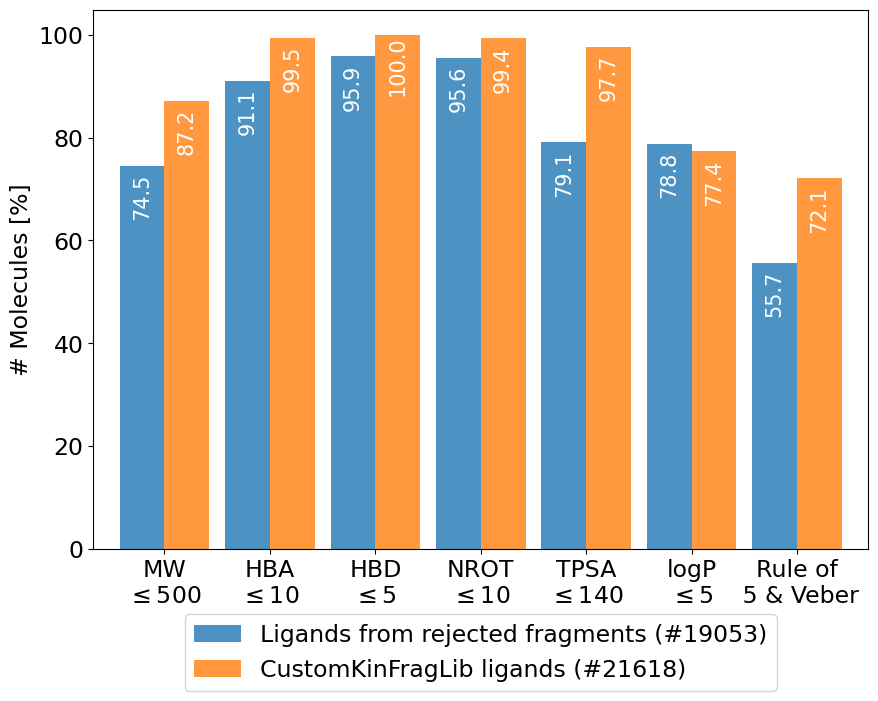

In [42]:
# Code taken from KinFragLib Notebook 4.2
ax = bar_data_subset.plot(
    kind='bar',
    width=0.85,
    rot=0,
    figsize=(10, 7),
    color=['tab:blue', 'tab:orange'], 
    alpha=0.8
)

# Edit labels for y axis and x/y ticks
plt.ylabel('# Molecules [%]', fontsize=17)
plt.xticks(range(7), ['MW\n'+r'$\leq 500$', 'HBA\n'+r'$\leq 10$', 'HBD\n'+r'$\leq 5$', 'NROT\n'+r'$\leq 10$', 'TPSA\n'+r'$\leq 140$', 'logP\n'+r'$\leq 5$' , 'Rule of\n 5 & Veber'], fontsize=17)
plt.yticks(fontsize=17)
plt.legend(fontsize=17, loc='upper left')
legend = plt.legend(loc='upper center', 
           bbox_to_anchor=(0.5,-.1),
           fontsize=17
          )

# Add percentages to bars
bars = ax.patches
bar_labels = bar_data_subset.transpose().values.flatten()
for bar, label in zip(bars, bar_labels):
    
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() - 6,
        round(label, 1), 
        ha='center', 
        va='center', 
        fontsize=15,
        color='white',
        rotation=90
    )

plt.savefig("figures/ruleof5_molecules.pdf", bbox_inches='tight')
plt.show()

In [33]:
# calculate QED score for all molecules 
qed_mols = [QED.qed(mol) for mol in sampled_mols_custom]
qed_refs = [QED.qed(mol) for mol in sampled_mols]

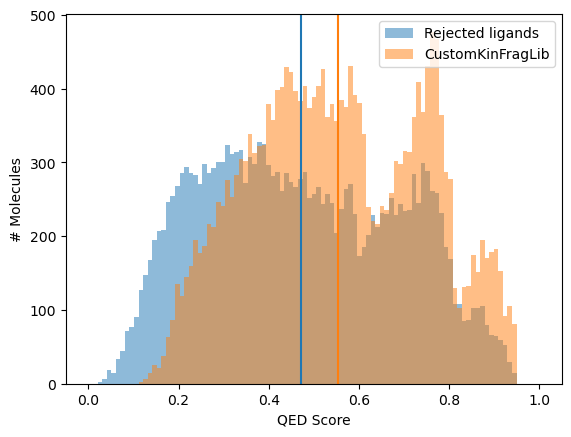

In [34]:
bins = np.linspace(0, 1, 100)
plt.hist(qed_refs, bins, alpha=0.5, label='Rejected ligands', color="tab:blue")
plt.hist(qed_mols, bins, alpha=0.5, label='CustomKinFragLib', color="tab:orange")
plt.axvline(np.mean(qed_mols), color="tab:orange")
plt.axvline(np.mean(qed_refs), color="tab:blue")
plt.legend(loc='upper right')
plt.xlabel("QED Score")
plt.ylabel("# Molecules")
plt.savefig("figures/qed_distribution_molecules.pdf")
plt.show()

### 6.2 Synthesizability 

We calculate the SYBA score and compare the molecules to the Enamine REAL Space, by extracting the most similar molecule and analyzing how similar our chemical space is to the commercial library. 

In [35]:
syba = SybaClassifier()  # loading the classifier to calculate the SYBA score
syba.fitDefaultScore()  # fit the classifier to the default score

syba_mols = [syba.predict(mol=mol) for mol in sampled_mols_custom]
syba_refs = [syba.predict(mol=mol) for mol in sampled_mols]

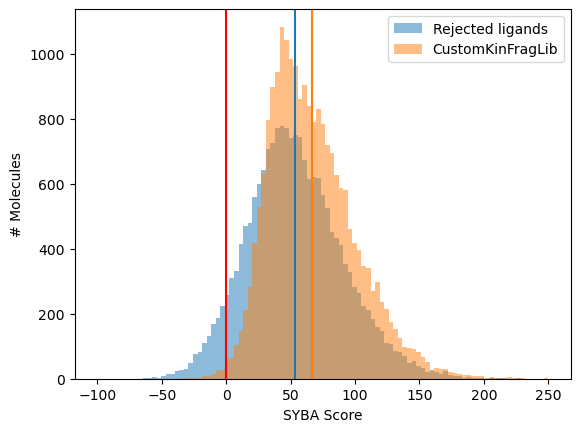

In [36]:
bins = np.linspace(-100, 250, 100)

plt.hist(syba_refs, bins, alpha=0.5, label='Rejected ligands', color="tab:blue")
plt.hist(syba_mols, bins, alpha=0.5, label='CustomKinFragLib', color="tab:orange")
plt.axvline(np.mean(syba_mols), color="tab:orange")
plt.axvline(np.mean(syba_refs), color="tab:blue")
plt.axvline(0, color="red")
plt.legend(loc='upper right')
plt.xlabel("SYBA Score")
plt.ylabel("# Molecules")
plt.savefig('figures/syba_distribution_molecules.pdf')
plt.show()

We extract the most similar molecule from Enamine REAL Space for each molecule in our chemical space. We used [SpaceLight](https://pubs.acs.org/doi/full/10.1021/acs.jcim.0c00850) for the similarity search. 

**Note**: We deposited our results in the combinatorial library data folder, please first download the data from zenodo to run this notebook. 

In [37]:
enamine_subset_df = pd.read_csv(str(PATH_TO_DATA / "combinatorial_library" / "custom_enamine_search_sampled.csv"))
ref_enamine_subset_df = pd.read_csv(str(PATH_TO_DATA / "combinatorial_library" / "reference_enamine_search_sampled.csv"))

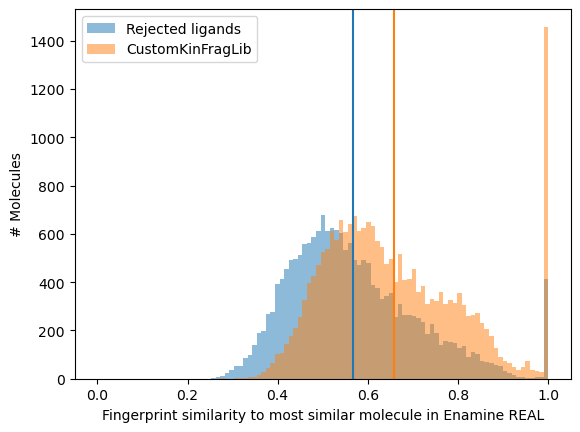

In [38]:
bins = np.linspace(0, 1, 100)

plt.hist(ref_enamine_subset_df["fingerprint-similarity"], bins, alpha=0.5, label="Rejected ligands")
plt.hist(enamine_subset_df["fingerprint-similarity"], bins, alpha=0.5, label="CustomKinFragLib")
plt.axvline(np.mean(enamine_subset_df["fingerprint-similarity"]), color="tab:orange")
plt.axvline(np.mean(ref_enamine_subset_df["fingerprint-similarity"]), color="tab:blue")
plt.legend(loc='upper left')
plt.ylabel("# Molecules")
plt.xlabel("Fingerprint similarity to most similar molecule in Enamine REAL")
plt.savefig("figures/enamine_similarity_enumerated_mols.pdf")
plt.show()

In [39]:
len(enamine_subset_df[enamine_subset_df['fingerprint-similarity'] == 1.0]) / len(enamine_subset_df)

0.06730502359145157

In [40]:
len(ref_enamine_subset_df[ref_enamine_subset_df['fingerprint-similarity'] == 1.0]) / len(ref_enamine_subset_df)

0.021926348602525493